In [ ]:
#import packages
from __future__ import print_function
import tensorflow as tf
import keras
from tensorflow.keras import datasets, layers, models
import pandas as pd
import numpy as np
from keras.optimizers import Adam, SGD
# import warnings
# warnings.filterwarnings('ignore')
import cv2
from tensorflow.keras.utils import img_to_array, array_to_img, load_img, to_categorical
# from keras.preprocessing.image import ImageDataGenerator

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_lbl1 = pd.read_csv(r'/content/drive/MyDrive/pisc/annotations.csv')

df_lbl1

,id_name,relation
0,1,4.0
1,2,1.0
2,3,4.0
3,4,4.0
4,5,4.0
...,...,...
41376,41377,2.0
41377,41378,4.0
41378,41379,3.0
41379,41380,6.0


In [ ]:
import zipfile
dn='/content/drive/MyDrive/pisc/allimg.npy.zip'
zip_ref = zipfile.ZipFile(dn, "r")
zip_ref.extractall('/content/drive/MyDrive/pisc/')
zip_ref.close()

In [ ]:
data_x = []
data_x=np.load('/content/drive/MyDrive/pisc/allimg.npy')

In [ ]:
data_y = []
for index, row in df_lbl1.iterrows():
  data_y.append(int(row['relation']))

In [ ]:
uniques, ids = np.unique(data_y, return_inverse=True)
labels1 = to_categorical(ids)
labels=ids
labels1

array([[0., 0., 0., 1., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       ...,
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 1.]], dtype=float32)

In [ ]:
from sklearn.model_selection import train_test_split

#Splitting
X_train, X_test, y_train, y_test = train_test_split(data_x, labels1, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
print("Train: ", len(X_train), " Test; ",len(X_val), " Test: ",len(X_test))

Train:  33104  Test;  4138  Test:  4139


In [ ]:
print(X_train.shape)
print(y_train.shape)
input_shape = X_train[0].shape
print(input_shape)

(33104, 224, 224, 3)
(33104, 6)
(224, 224, 3)


In [ ]:
print(y_train.dtype)

float32


In [ ]:
y_train_l = np.argmax(y_train, axis=1)
ul = np.unique(y_train_l)
print(ul)

[0 1 2 3 4 5]


In [ ]:
y_val_l = np.argmax(y_val, axis=1)
ulv = np.unique(y_val_l)
print(ulv)

[0 1 2 3 4 5]


In [ ]:
y_test_l = np.argmax(y_test, axis=1)
ult = np.unique(y_test_l)
print(ult)

[0 1 2 3 4 5]


In [ ]:
# y1_train = y_train.astype(int)

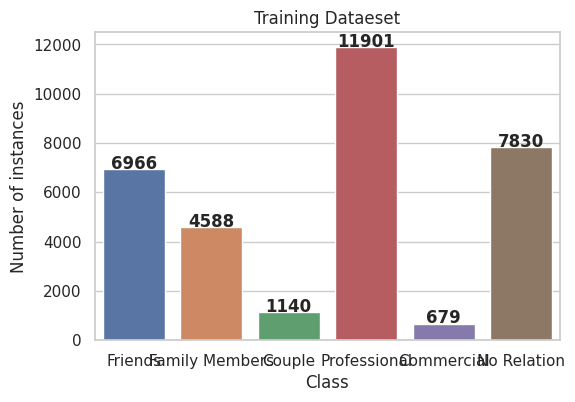

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
num_classes = len(class_names) #np.max(y_train_l) + 1
class_counts = np.zeros(num_classes, dtype=int)
for label in y_train_l:
    class_counts[label] += 1


sns.set(style="whitegrid")
plt.figure(figsize=(6, 4))
plt.title("Training Dataeset")
ax = sns.barplot(x=np.arange(num_classes), y=class_counts)
# ax.set_xticklabels(["Class {}".format(i+1) for i in range(num_classes)])
ax.set_xticklabels(class_names)
ax.set(xlabel="Class", ylabel="Number of instances")

for i, count in enumerate(class_counts):
    ax.text(i, count + 5, str(count), horizontalalignment='center', fontweight='bold')

plt.show()

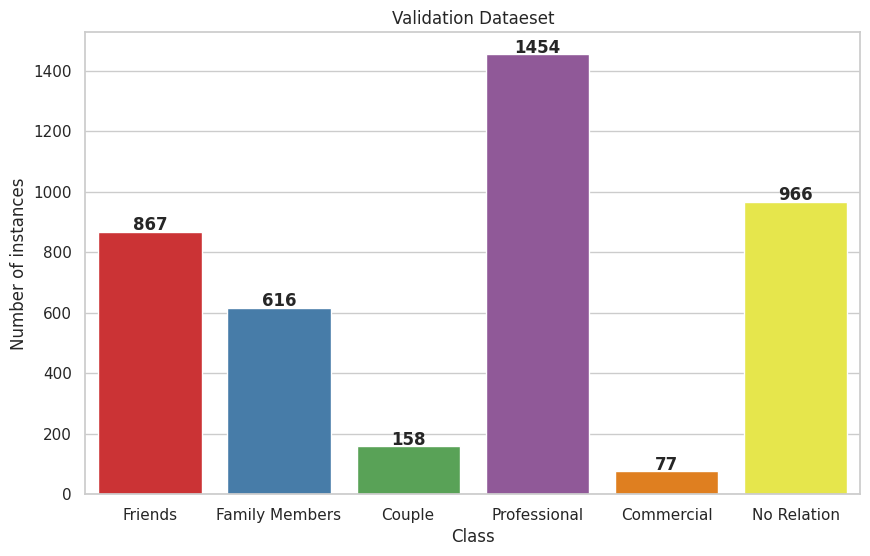

In [ ]:
class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
num_classes = len(class_names) #np.max(y_train_l) + 1
class_counts = np.zeros(num_classes, dtype=int)
for label in y_val_l:
    class_counts[label] += 1



sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
plt.title("Validation Dataeset")
ax = sns.barplot(x=np.arange(num_classes), y=class_counts, palette= "Set1")
# ax.set_xticklabels(["Class {}".format(i+1) for i in range(num_classes)])
ax.set_xticklabels(class_names)
ax.set(xlabel="Class", ylabel="Number of instances")


for i, count in enumerate(class_counts):
    ax.text(i, count + 5, str(count), horizontalalignment='center', fontweight='bold')

plt.show()

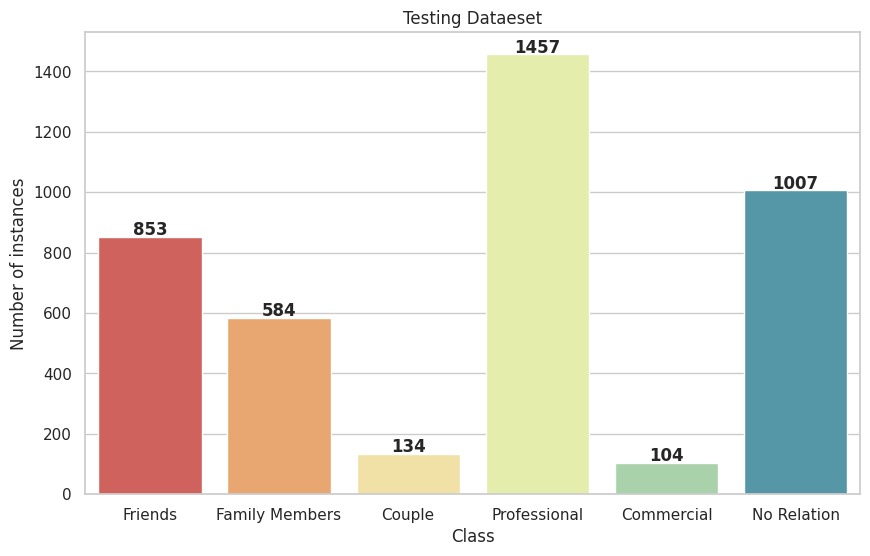

In [ ]:
class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']
num_classes = len(class_names) #np.max(y_train_l) + 1
class_counts = np.zeros(num_classes, dtype=int)
for label in y_test_l:
    class_counts[label] += 1


sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
plt.title("Testing Dataeset")
ax = sns.barplot(x=np.arange(num_classes), y=class_counts, palette= "Spectral")
# ax.set_xticklabels(["Class {}".format(i+1) for i in range(num_classes)])
ax.set_xticklabels(class_names)
ax.set(xlabel="Class", ylabel="Number of instances")

for i, count in enumerate(class_counts):
    ax.text(i, count + 5, str(count), horizontalalignment='center', fontweight='bold')

plt.show()

new

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the hyperparameters
epochs=100
num_classes = 6
image_size = 224
patch_size = 16
num_patches = (image_size // patch_size) ** 2
embedding_dim = 128
num_heads = 8
mlp_dim = 256
dropout_rate = 0.1 #0.5
batch_size = 32
epochs = 50
learning_rate = 0.0001


# # CVT model

inputs = keras.Input(shape=(image_size, image_size, 3))

# Convolutional layers
x = layers.Conv2D(128, kernel_size=3, strides=2, padding="same", kernel_regularizer=keras.regularizers.l2(0.001))(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(256, kernel_size=3, strides=2, padding="same", kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(512, kernel_size=3, strides=2, padding="same", kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(1024, kernel_size=3, strides=2, padding="same", kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.Conv2D(2048, kernel_size=3, strides=2, padding="same", kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

# CVT layers
x = layers.Reshape((num_patches, -1))(x)
x = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embedding_dim, dropout=dropout_rate)(x, x)
x = layers.Dropout(dropout_rate)(x)
x = layers.LayerNormalization()(x)

x = layers.Dense(mlp_dim, activation="relu", kernel_regularizer=keras.regularizers.l2(0.001))(x)
x = layers.Dropout(dropout_rate)(x)
x = layers.Dense(embedding_dim)(x)

# Classification head
x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

# # Use transfer learning
base_model = keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=(image_size, image_size, 3))

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

modelb1 = keras.Model(inputs=base_model.input, outputs=outputs)


modelb1.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [ ]:
history = modelb1.fit(X_train, y_train, epochs=100,
                     validation_data=(X_val, y_val))

Epoch 1/100
1035/1035 [==============================] - 126s 70ms/step - loss: 0.9629 - accuracy: 0.6395 - val_loss: 0.9449 - val_accuracy: 0.6479
Epoch 2/100
1035/1035 [==============================] - 65s 63ms/step - loss: 0.5359 - accuracy: 0.8125 - val_loss: 0.7883 - val_accuracy: 0.7231
Epoch 3/100
1035/1035 [==============================] - 65s 62ms/step - loss: 0.2900 - accuracy: 0.8978 - val_loss: 1.0140 - val_accuracy: 0.7221
Epoch 4/100
1035/1035 [==============================] - 65s 62ms/step - loss: 0.1847 - accuracy: 0.9351 - val_loss: 1.1573 - val_accuracy: 0.6796
Epoch 5/100
1035/1035 [==============================] - 65s 63ms/step - loss: 0.1444 - accuracy: 0.9494 - val_loss: 1.2849 - val_accuracy: 0.7243
Epoch 6/100
1035/1035 [==============================] - 65s 63ms/step - loss: 0.1147 - accuracy: 0.9598 - val_loss: 0.9163 - val_accuracy: 0.7765
Epoch 7/100
1035/1035 [==============================] - 65s 62ms/step - loss: 0.1011 - accuracy: 0.9651 - val_loss: 

In [ ]:
# modelb.save('pcvt.h5')

In [ ]:
modelb1.save('/content/drive/MyDrive/pisc/pcvtnew.h5')

In [ ]:
import pickle

with open('history.pickle', 'wb') as file_pi:
    pickle.dump(history.history, file_pi)

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('/content/drive/MyDrive/pisc/pcvtnew.h5')

In [ ]:
from sklearn.metrics import average_precision_score

# Use the model to make predictions on the test dataset
predicted_probs = model.predict(X_test)

# Calculate the average precision for each class
average_precision = average_precision_score(y_test, predicted_probs, average=None)

# Calculate the mean average precision
mean_average_precision = average_precision_score(y_test, predicted_probs, average='macro')

130/130 [==============================] - 3s 17ms/step


In [ ]:
print(mean_average_precision)

0.753295358341276


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print('Test loss:', loss)
print('Test accuracy:', accuracy)

130/130 [==============================] - 4s 20ms/step - loss: 1.3572 - accuracy: 0.7681
Test loss: 1.3572025299072266
Test accuracy: 0.7680599093437195


In [ ]:
y_pred = model.predict(X_test)
y_pred_labels = uniques[np.argmax(y_pred, axis=1)]
print(y_pred_labels)
y_test_labels = uniques[np.argmax(y_test, axis=1)]
print(y_pred_labels)
accuracy = np.mean(y_pred_labels == y_test_labels)
print('Test accuracy:', accuracy)

130/130 [==============================] - 2s 16ms/step
[1 4 6 ... 4 6 6]
[1 4 6 ... 4 6 6]
Test accuracy: 0.7680599178545542


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_labels, y_pred_labels)

print('Confusion matrix:')
print(cm)

Confusion matrix:
[[ 656   68   34   37   15   43]
 [  84  438   26   12    2   22]
 [  54   15   43   12    3    7]
 [ 124   38   30 1150   25   90]
 [  19   14    7    7   46   11]
 [  61   38   14   34   14  846]]


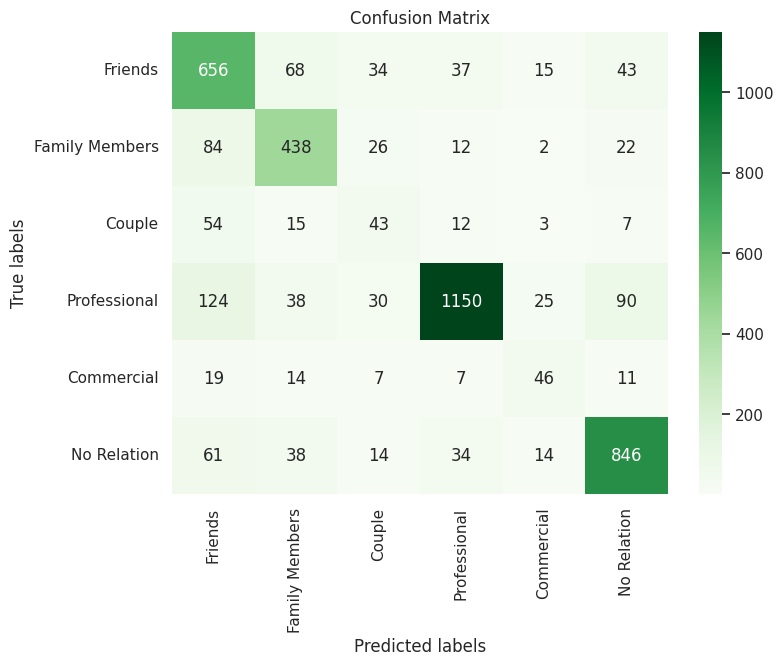

In [ ]:
class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']


cm = confusion_matrix(y_test_labels, y_pred_labels)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_df, fmt='d', annot=True, cmap='Greens', ax=ax)

plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')

plt.show()

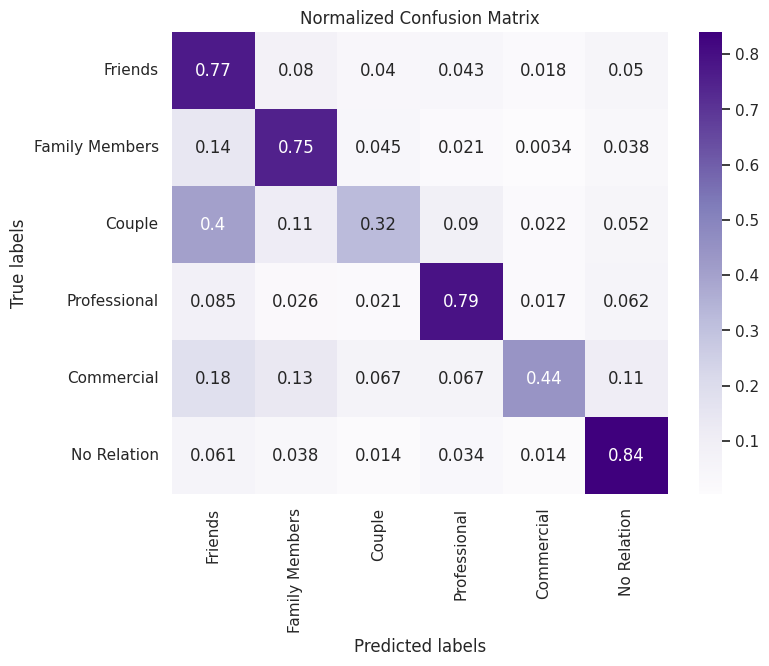

In [ ]:
class_names = ['Friends', 'Family Members', 'Couple', 'Professional', 'Commercial', 'No Relation']

cm = confusion_matrix(y_test_labels, y_pred_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

cm_norm_df = pd.DataFrame(cm_norm, index=class_names, columns=class_names)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, cmap='Purples', ax=ax)

plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Normalized Confusion Matrix')

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test_labels, y_pred_labels, target_names=class_names))

                precision    recall  f1-score   support

       Friends       0.66      0.77      0.71       853
Family Members       0.72      0.75      0.73       584
        Couple       0.28      0.32      0.30       134
  Professional       0.92      0.79      0.85      1457
    Commercial       0.44      0.44      0.44       104
   No Relation       0.83      0.84      0.84      1007

      accuracy                           0.77      4139
     macro avg       0.64      0.65      0.64      4139
  weighted avg       0.78      0.77      0.77      4139



In [ ]:
report = classification_report(y_test_labels, y_pred_labels, target_names=class_names, output_dict=True)

print("Weighted Average Precision: {:.2f}".format(report['weighted avg']['precision']))
print("Weighted Average Recall: {:.2f}".format(report['weighted avg']['recall']))
print("Weighted Average F1-score: {:.2f}".format(report['weighted avg']['f1-score']))
print("Weighted Average Support: {:.2f}".format(report['weighted avg']['support']))

Weighted Average Precision: 0.78
Weighted Average Recall: 0.77
Weighted Average F1-score: 0.77
Weighted Average Support: 4139.00
